# Analisis

Lucho May| 2026 <br>
Tombi by Kvi Baba

### Import Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow
import re
import warnings

warnings.filterwarnings('ignore')

### Import dataset

In [2]:
df1 = pd.read_csv(r"listings_plataforma_A.csv")
df1_raw = df1.copy()
df_a = df1.copy()
df1.drop(["titulo"], axis=1, inplace=True)
df1.head()

,id_aviso,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,banios,antiguedad,cochera,balcon,amenities,latitud,longitud,fecha_publicacion
0,A-700480,BELGRANO,Departamento,1.267.000,140298.0,75,75.0,4 amb.,3.0,2.0,4 años,Sí,Sí,NaN,-34.549646421652646,-58.462834001141694,04/01/2025
1,A-220016,Almagro,Departamento,584.000,77822.0,39,NaN,2 amb.,1.0,NaN,6,No,No,NaN,-34.60873815826056,-58.43909947532191,15/01/2024
2,A-492142,Flores,Departamento,252.000,NaN,35 m²,35.0,2,NaN,1.0,23,Sí,No,NaN,"-34,62205081312381",-58.45626733855754,07/03/2024
3,A-675147,Belgrano,PH,546.000,NaN,38 m²,38.0,2 amb.,1.0,1.0,A estrenar,No,No,Pileta,-34.574756771995716,-58.463757544997684,04/12/2024
4,A-307536,Villa Urquiza,Departamento,337.000,52942.0,33 m²,NaN,1,NaN,1.0,2,No,Sí,NaN,-34.55428879305003,-58.4866156408398,25/02/2024


Nota: Con respecto a las expensas, solo se hara un simple grafico y luego se pasara a boolean, ya que estos datos solo aparecen en este dataset, el resto no lo posee

In [3]:
df1.expensas.describe().T

count    1.990000e+03
mean     6.190570e+05
std      2.748585e+06
min      7.775000e+03
25%      5.420750e+04
50%      8.668650e+04
75%      1.413370e+05
max      4.520470e+07
Name: expensas, dtype: float64

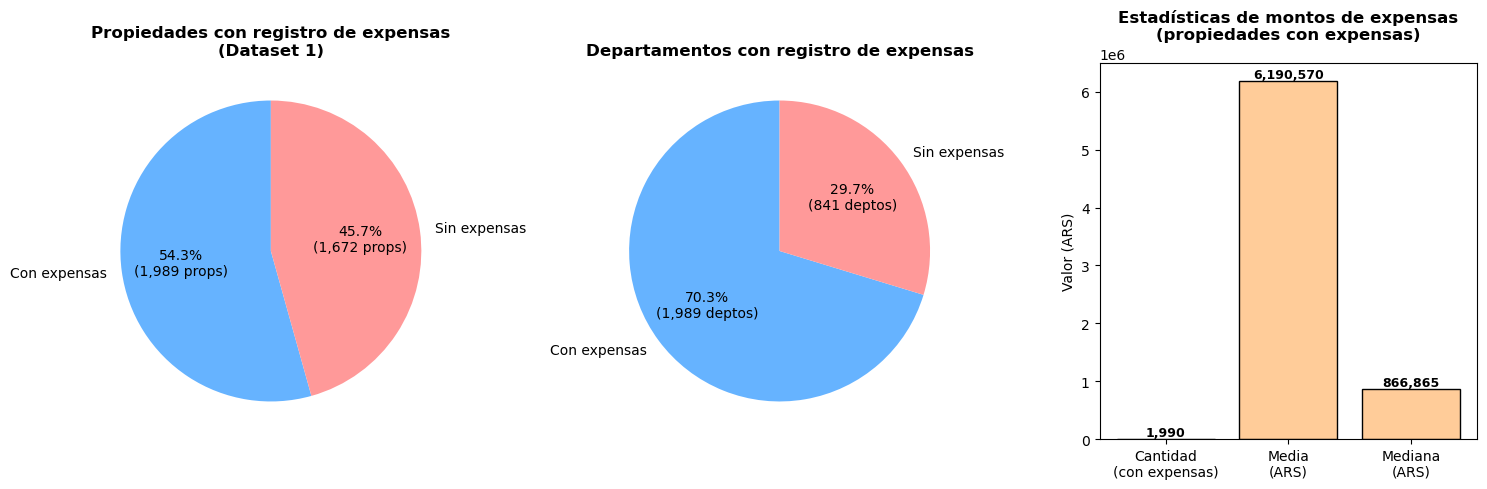


📊 ANÁLISIS DE EXPENSAS - DATASET 1
📌 Total de propiedades en el dataset: 3,662
💰 Propiedades con registro de expensas: 1,990 (54.3%)
❌ Propiedades sin registro de expensas: 1,672 (45.7%)

📌 Total de DEPARTAMENTOS: 2,831
💰 Departamentos con expensas: 1,990 (70.3%)

📈 Estadísticas de montos de expensas (solo propiedades con datos):
   • Cantidad de registros: 1,990
   • Media: $6,190,570.03 ARS
   • Mediana: $866,865.00 ARS
   • Mínimo: $77,750.00 ARS
   • Máximo: $452,047,000.00 ARS


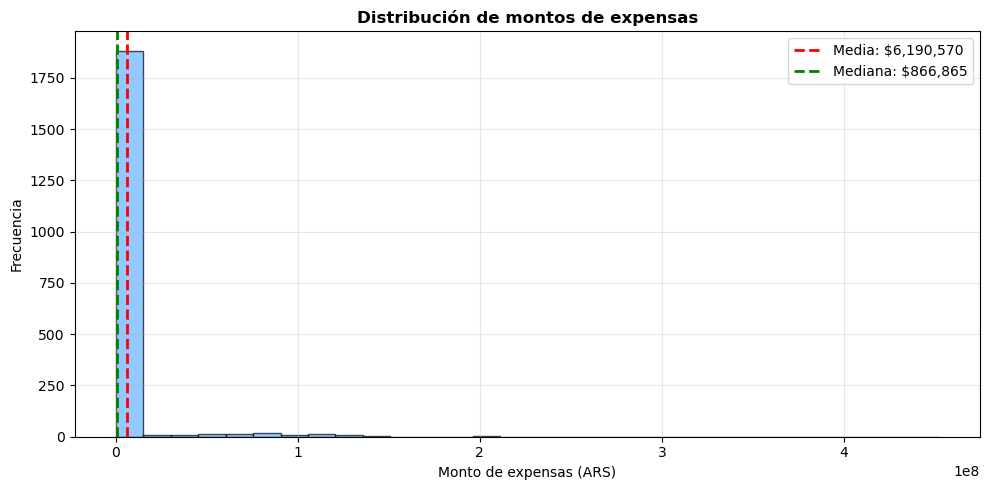

In [4]:
# Limpieza básica de expensas (como haríamos en el pipeline)
def clean_expenses(exp_str):
    if pd.isna(exp_str):
        return np.nan
    exp_str = str(exp_str).strip()
    # Extraer solo el número (puede tener puntos de miles)
    num_str = re.sub(r'[^\d]', '', exp_str)
    if num_str.isdigit():
        return float(num_str)
    return np.nan
df_a['expensas_clean'] = df_a['expensas'].apply(clean_expenses)

# Crear columna 'tiene_expensas' (True si no es NaN y > 0)
df_a['tiene_expensas'] = df_a['expensas_clean'].notna() & (df_a['expensas_clean'] > 0)

# Para el segundo gráfico, filtrar solo departamentos
df_a_departamentos = df_a[df_a['tipo'] == 'Departamento'].copy()
df_a_departamentos['tiene_expensas_dep'] = df_a_departamentos['expensas_clean'].notna() & (df_a_departamentos['expensas_clean'] > 0)

# Configurar figura con 3 subplots
fig = plt.figure(figsize=(15, 5))


#  Proporción de propiedades con expensas

ax1 = fig.add_subplot(1, 3, 1)
expensas_counts = df_a['tiene_expensas'].value_counts()
labels = ['Con expensas', 'Sin expensas']
colors = ['#66b3ff', '#ff9999']

# Calcular porcentajes
total = len(df_a)
con_exp = expensas_counts.get(True, 0)
sin_exp = expensas_counts.get(False, 0)

wedges, texts, autotexts = ax1.pie(
    [con_exp, sin_exp],
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total):,} props)',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10}
)
ax1.set_title('Propiedades con registro de expensas\n(Dataset 1)', fontsize=12, fontweight='bold')


# Solo Departamentos con expensas

ax2 = fig.add_subplot(1, 3, 2)
expensas_counts_dep = df_a_departamentos['tiene_expensas_dep'].value_counts()
labels_dep = ['Con expensas', 'Sin expensas']
total_dep = len(df_a_departamentos)
con_exp_dep = expensas_counts_dep.get(True, 0)
sin_exp_dep = expensas_counts_dep.get(False, 0)

wedges2, texts2, autotexts2 = ax2.pie(
    [con_exp_dep, sin_exp_dep],
    labels=labels_dep,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total_dep):,} deptos)',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10}
)
ax2.set_title('Departamentos con registro de expensas', fontsize=12, fontweight='bold')


# Barras - Estadísticas de montos de expensas

ax3 = fig.add_subplot(1, 3, 3)

# Filtrar solo propiedades con expensas > 0
expensas_validas = df_a[df_a['expensas_clean'] > 0]['expensas_clean']

# Calcular estadísticas
total_con_expensas = len(expensas_validas)
media_expensas = expensas_validas.mean()
mediana_expensas = expensas_validas.median()
min_expensas = expensas_validas.min()
max_expensas = expensas_validas.max()

# Crear barras
stats = ['Cantidad\n(con expensas)', 'Media\n(ARS)', 'Mediana\n(ARS)']
values = [total_con_expensas, media_expensas, mediana_expensas]

bars = ax3.bar(stats, values, color=['#66b3ff', '#ffcc99', '#ffcc99'], edgecolor='black', linewidth=1)

# Agregar etiquetas de valor sobre las barras
for bar, val in zip(bars, values):
    if val > 1000:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_title('Estadísticas de montos de expensas\n(propiedades con expensas)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Valor (ARS)')
ax3.tick_params(axis='x', labelsize=10)

# Ajustar layout
plt.tight_layout()
plt.show()

# Información adicional en consola
print("\n" + "="*60)
print("📊 ANÁLISIS DE EXPENSAS - DATASET 1")
print("="*60)
print(f"📌 Total de propiedades en el dataset: {len(df_a):,}")
print(f"💰 Propiedades con registro de expensas: {con_exp:,} ({con_exp/len(df_a)*100:.1f}%)")
print(f"❌ Propiedades sin registro de expensas: {sin_exp:,} ({sin_exp/len(df_a)*100:.1f}%)")
print(f"\n📌 Total de DEPARTAMENTOS: {total_dep:,}")
print(f"💰 Departamentos con expensas: {con_exp_dep:,} ({con_exp_dep/total_dep*100:.1f}%)")
print(f"\n📈 Estadísticas de montos de expensas (solo propiedades con datos):")
print(f"   • Cantidad de registros: {total_con_expensas:,}")
print(f"   • Media: ${media_expensas:,.2f} ARS")
print(f"   • Mediana: ${mediana_expensas:,.2f} ARS")
print(f"   • Mínimo: ${min_expensas:,.2f} ARS")
print(f"   • Máximo: ${max_expensas:,.2f} ARS")
print("="*60)

# Extra: Mostrar distribución de expensas en un histograma (opcional)
fig2, ax = plt.subplots(figsize=(10, 5))
ax.hist(expensas_validas, bins=30, edgecolor='black', alpha=0.7, color='#66b3ff')
ax.axvline(media_expensas, color='red', linestyle='dashed', linewidth=2, label=f'Media: ${media_expensas:,.0f}')
ax.axvline(mediana_expensas, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: ${mediana_expensas:,.0f}')
ax.set_xlabel('Monto de expensas (ARS)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de montos de expensas', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Debido a la escasez de datos disponibles, la presencia de numerosas ausencias y la existencia de valores atípicos —donde en algunos casos el monto de las expensas igualaba o incluso superaba el valor del alquiler—, especialmente en el caso de departamentos, se evaluó el impacto de esta variable (que representaba aproximadamente el 10% de los datos al combinar los tres datasets). En función de este análisis, se decidió reemplazarla por una variable booleana.

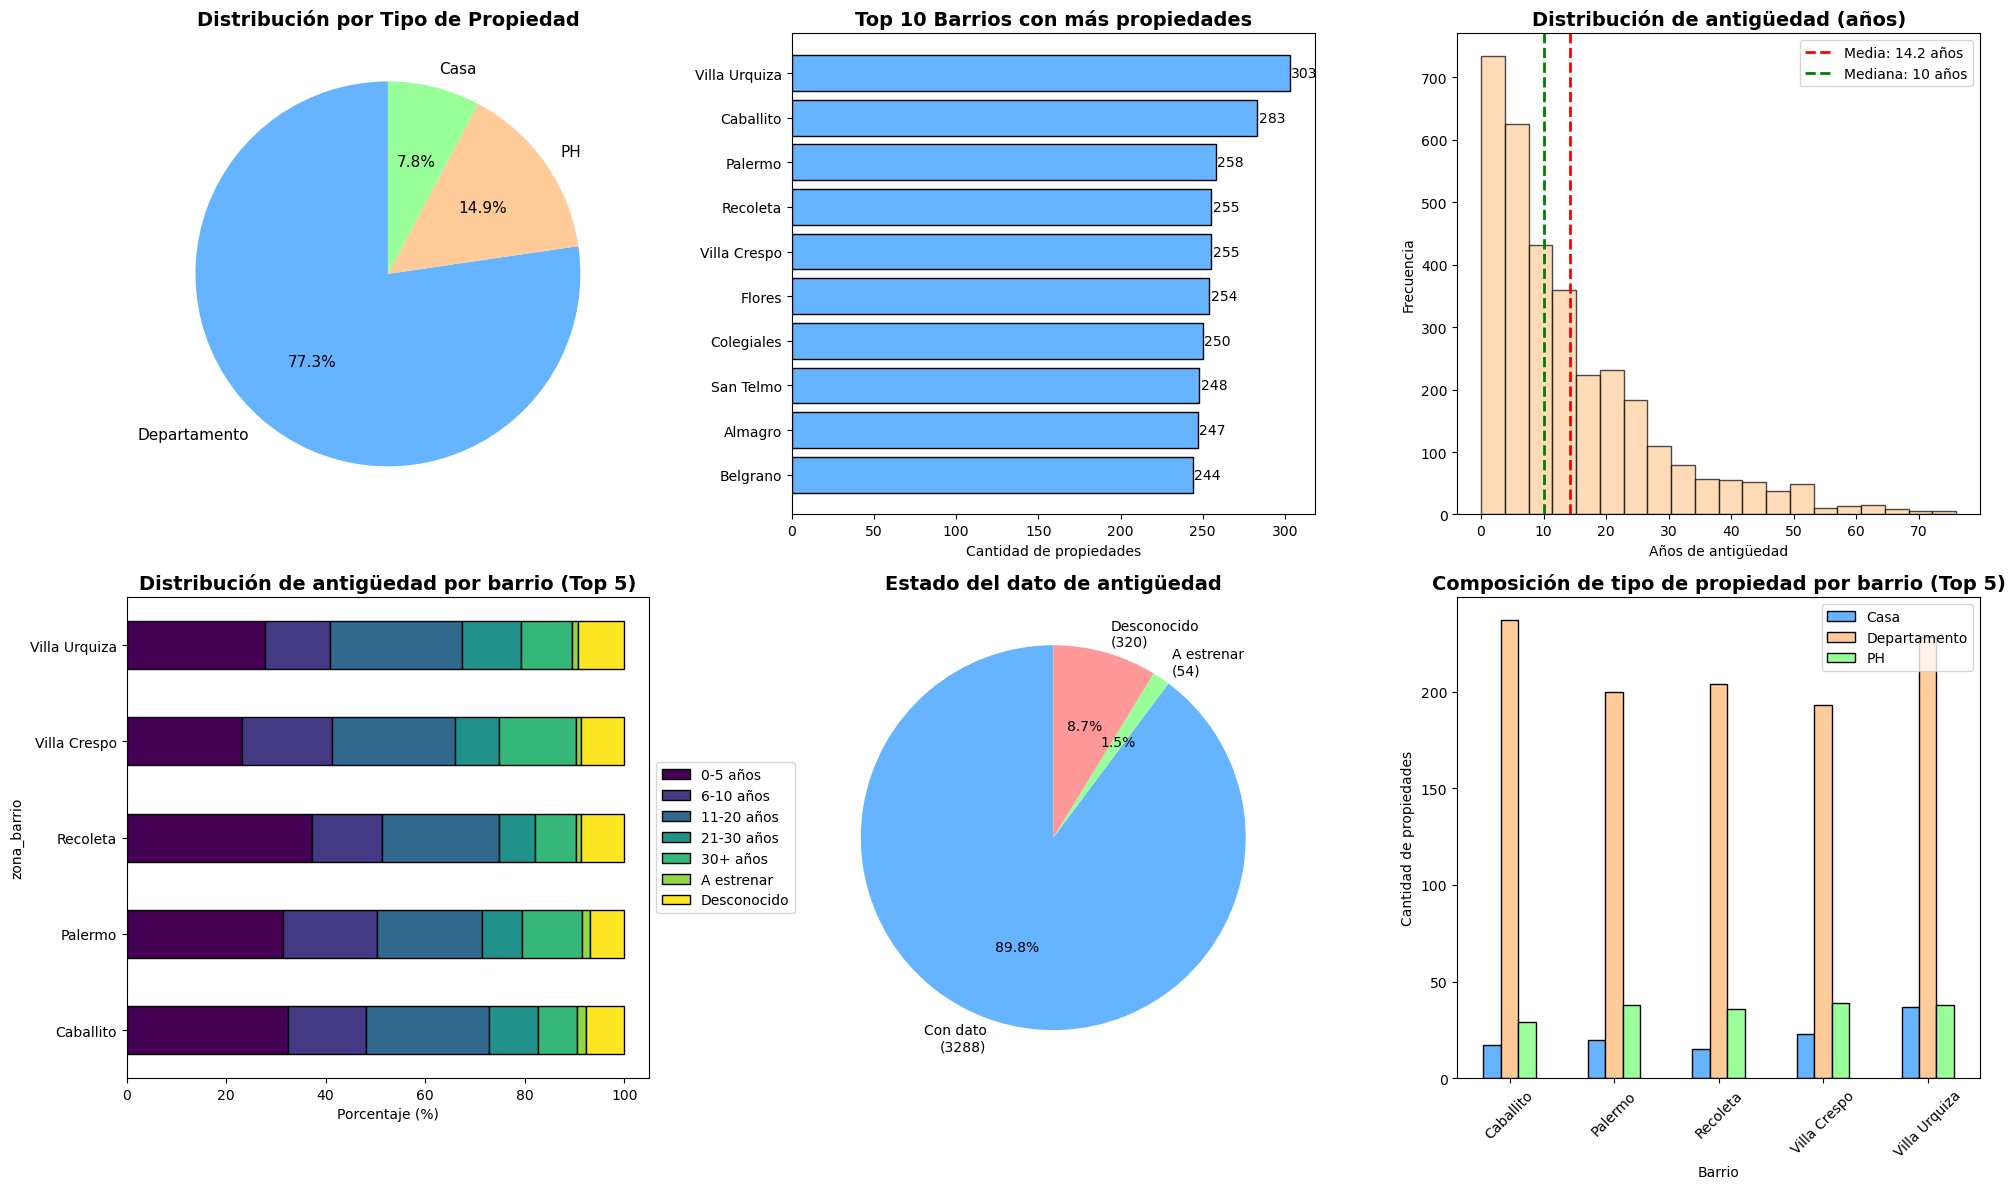


📊 ANÁLISIS COMPLETO DEL DATASET INMOBILIARIO

📌 1. DISTRIBUCIÓN POR TIPO DE PROPIEDAD:
--------------------------------------------------
   • Departamento: 2,831 (77.3%)
   • PH: 547 (14.9%)
   • Casa: 284 (7.8%)

📌 2. TOP 10 BARRIOS CON MÁS PROPIEDADES:
--------------------------------------------------
   1. Villa Urquiza: 303 propiedades
   2. Caballito: 283 propiedades
   3. Palermo: 258 propiedades
   4. Recoleta: 255 propiedades
   5. Villa Crespo: 255 propiedades
   6. Flores: 254 propiedades
   7. Colegiales: 250 propiedades
   8. San Telmo: 248 propiedades
   9. Almagro: 247 propiedades
   10. Belgrano: 244 propiedades

📌 3. ESTADÍSTICAS DE ANTIGÜEDAD:
--------------------------------------------------
   • Con dato numérico: 3,288 (89.8%)
   • A estrenar: 54 (1.5%)
   • Desconocido: 320 (8.7%)

   📈 Estadísticas de propiedades con dato numérico:
   • Media: 14.2 años
   • Mediana: 10 años
   • Mínimo: 0 años
   • Máximo: 76 años



In [5]:
def clean_age(value):
    if pd.isna(value):
        return 'Desconocido'
    value = str(value).strip().lower()
    if 'estrenar' in value:
        return 'A estrenar'
    match = re.search(r'(\d+)', value)
    if match:
        return int(match.group(1))
    return 'Desconocido'

def age_category(years):
    if years == 'Desconocido':
        return 'Desconocido'
    if years == 'A estrenar':
        return 'A estrenar'
    if years <= 5:
        return '0-5 años'
    elif years <= 10:
        return '6-10 años'
    elif years <= 20:
        return '11-20 años'
    elif years <= 30:
        return '21-30 años'
    else:
        return '30+ años'

df_a['antiguedad_num'] = df_a['antiguedad'].apply(clean_age)
df_a['antiguedad_categoria'] = df_a['antiguedad_num'].apply(age_category)


# GRÁFICO DE TORTA: Tipo de propiedad (PH, Casa, Departamento)

fig = plt.figure(figsize=(20, 12))

ax1 = fig.add_subplot(2, 3, 1)
tipo_counts = df_a['tipo'].value_counts()
colors_tipo = {'Departamento': '#66b3ff', 'PH': '#ffcc99', 'Casa': '#99ff99'}
pie_colors = [colors_tipo.get(x, '#cccccc') for x in tipo_counts.index]

ax1.pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%', 
        colors=pie_colors, startangle=90, textprops={'fontsize': 11})
ax1.set_title('Distribución por Tipo de Propiedad', fontsize=14, fontweight='bold')


# GRÁFICO DE BARRAS: Top barrios con más propiedades

ax2 = fig.add_subplot(2, 3, 2)
barrios_counts = df_a['zona_barrio'].value_counts().head(10)
ax2.barh(barrios_counts.index, barrios_counts.values, color='#66b3ff', edgecolor='black')
ax2.set_xlabel('Cantidad de propiedades')
ax2.set_title('Top 10 Barrios con más propiedades', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

for i, v in enumerate(barrios_counts.values):
    ax2.text(v + 1, i, str(v), va='center')


# GRÁFICO DE BARRAS: Distribución de años de antigüedad

ax3 = fig.add_subplot(2, 3, 3)
edad_numerica = df_a[df_a['antiguedad_num'].apply(lambda x: isinstance(x, int))]['antiguedad_num']
if len(edad_numerica) > 0:
    ax3.hist(edad_numerica, bins=20, color='#ffcc99', edgecolor='black', alpha=0.7)
    ax3.axvline(edad_numerica.mean(), color='red', linestyle='dashed', linewidth=2, 
                label=f'Media: {edad_numerica.mean():.1f} años')
    ax3.axvline(edad_numerica.median(), color='green', linestyle='dashed', linewidth=2,
                label=f'Mediana: {edad_numerica.median():.0f} años')
    ax3.set_xlabel('Años de antigüedad')
    ax3.set_ylabel('Frecuencia')
    ax3.set_title('Distribución de antigüedad (años)', fontsize=14, fontweight='bold')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'Sin datos numéricos de antigüedad', ha='center', va='center', transform=ax3.transAxes)


# GRÁFICO DE BARRAS APILADAS: Antigüedad por barrio (Top 5)

ax4 = fig.add_subplot(2, 3, 4)
top_barrios = df_a['zona_barrio'].value_counts().head(5).index
df_top_barrios = df_a[df_a['zona_barrio'].isin(top_barrios)]
crosstab = pd.crosstab(df_top_barrios['zona_barrio'], df_top_barrios['antiguedad_categoria'], normalize='index') * 100
crosstab = crosstab[['0-5 años', '6-10 años', '11-20 años', '21-30 años', '30+ años', 'A estrenar', 'Desconocido']]
crosstab.plot(kind='barh', stacked=True, ax=ax4, colormap='viridis', edgecolor='black')
ax4.set_xlabel('Porcentaje (%)')
ax4.set_title('Distribución de antigüedad por barrio (Top 5)', fontsize=14, fontweight='bold')
ax4.legend(loc='center left', bbox_to_anchor=(1, 0.5))


#  GRÁFICO DE TORTA: Estado de antigüedad (Con dato vs Sin dato)

ax5 = fig.add_subplot(2, 3, 5)
tiene_dato = df_a[df_a['antiguedad_num'].apply(lambda x: isinstance(x, int))].shape[0]
a_estrenar = df_a[df_a['antiguedad_num'] == 'A estrenar'].shape[0]
desconocido = df_a[df_a['antiguedad_num'] == 'Desconocido'].shape[0]

antiguedad_status = [tiene_dato, a_estrenar, desconocido]
antiguedad_labels = [f'Con dato\n({tiene_dato})', f'A estrenar\n({a_estrenar})', f'Desconocido\n({desconocido})']
ax5.pie(antiguedad_status, labels=antiguedad_labels, autopct='%1.1f%%',
        colors=['#66b3ff', '#99ff99', '#ff9999'], startangle=90)
ax5.set_title('Estado del dato de antigüedad', fontsize=14, fontweight='bold')


# GRÁFICO DE BARRAS: Cantidad de propiedades por tipo en cada barrio (Top 5)

ax6 = fig.add_subplot(2, 3, 6)
df_top_barrios_tipo = df_a[df_a['zona_barrio'].isin(top_barrios)]
tipo_por_barrio = pd.crosstab(df_top_barrios_tipo['zona_barrio'], df_top_barrios_tipo['tipo'])
tipo_por_barrio.plot(kind='bar', ax=ax6, color=['#66b3ff', '#ffcc99', '#99ff99'], edgecolor='black')
ax6.set_xlabel('Barrio')
ax6.set_ylabel('Cantidad de propiedades')
ax6.set_title('Composición de tipo de propiedad por barrio (Top 5)', fontsize=14, fontweight='bold')
ax6.legend(loc='upper right')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# RESULTADOS EN CONSOLA

print("\n" + "="*70)
print("📊 ANÁLISIS COMPLETO DEL DATASET INMOBILIARIO")
print("="*70)

print("\n📌 1. DISTRIBUCIÓN POR TIPO DE PROPIEDAD:")
print("-"*50)
for tipo, count in tipo_counts.items():
    print(f"   • {tipo}: {count:,} ({count/len(df_a)*100:.1f}%)")

print("\n📌 2. TOP 10 BARRIOS CON MÁS PROPIEDADES:")
print("-"*50)
for i, (barrio, count) in enumerate(barrios_counts.items(), 1):
    print(f"   {i}. {barrio}: {count:,} propiedades")

print("\n📌 3. ESTADÍSTICAS DE ANTIGÜEDAD:")
print("-"*50)
print(f"   • Con dato numérico: {tiene_dato:,} ({tiene_dato/len(df_a)*100:.1f}%)")
print(f"   • A estrenar: {a_estrenar:,} ({a_estrenar/len(df_a)*100:.1f}%)")
print(f"   • Desconocido: {desconocido:,} ({desconocido/len(df_a)*100:.1f}%)")

if len(edad_numerica) > 0:
    print(f"\n   📈 Estadísticas de propiedades con dato numérico:")
    print(f"   • Media: {edad_numerica.mean():.1f} años")
    print(f"   • Mediana: {edad_numerica.median():.0f} años")
    print(f"   • Mínimo: {edad_numerica.min():.0f} años")
    print(f"   • Máximo: {edad_numerica.max():.0f} años")

print("\n" + "="*70)

- Tipo de propiedad:  
  77% son departamentos → el mercado está dominado por este tipo.
- Barrios con más oferta:  
  Villa Urquiza, Caballito, Palermo, Recoleta → alta publicación puede implicar mayor competencia.
- Antigüedad:  
  Promedio 14 años → predominan propiedades relativamente nuevas.
- Datos faltantes:  
  ~9% sin antigüedad → no deben ignorarse.

- El mercado es homogéneo (predominan departamentos).  
- Las diferencias principales están en:
  - Barrio  
  - Antigüedad  

Más oferta no implica mejor zona; puede indicar sobreoferta.

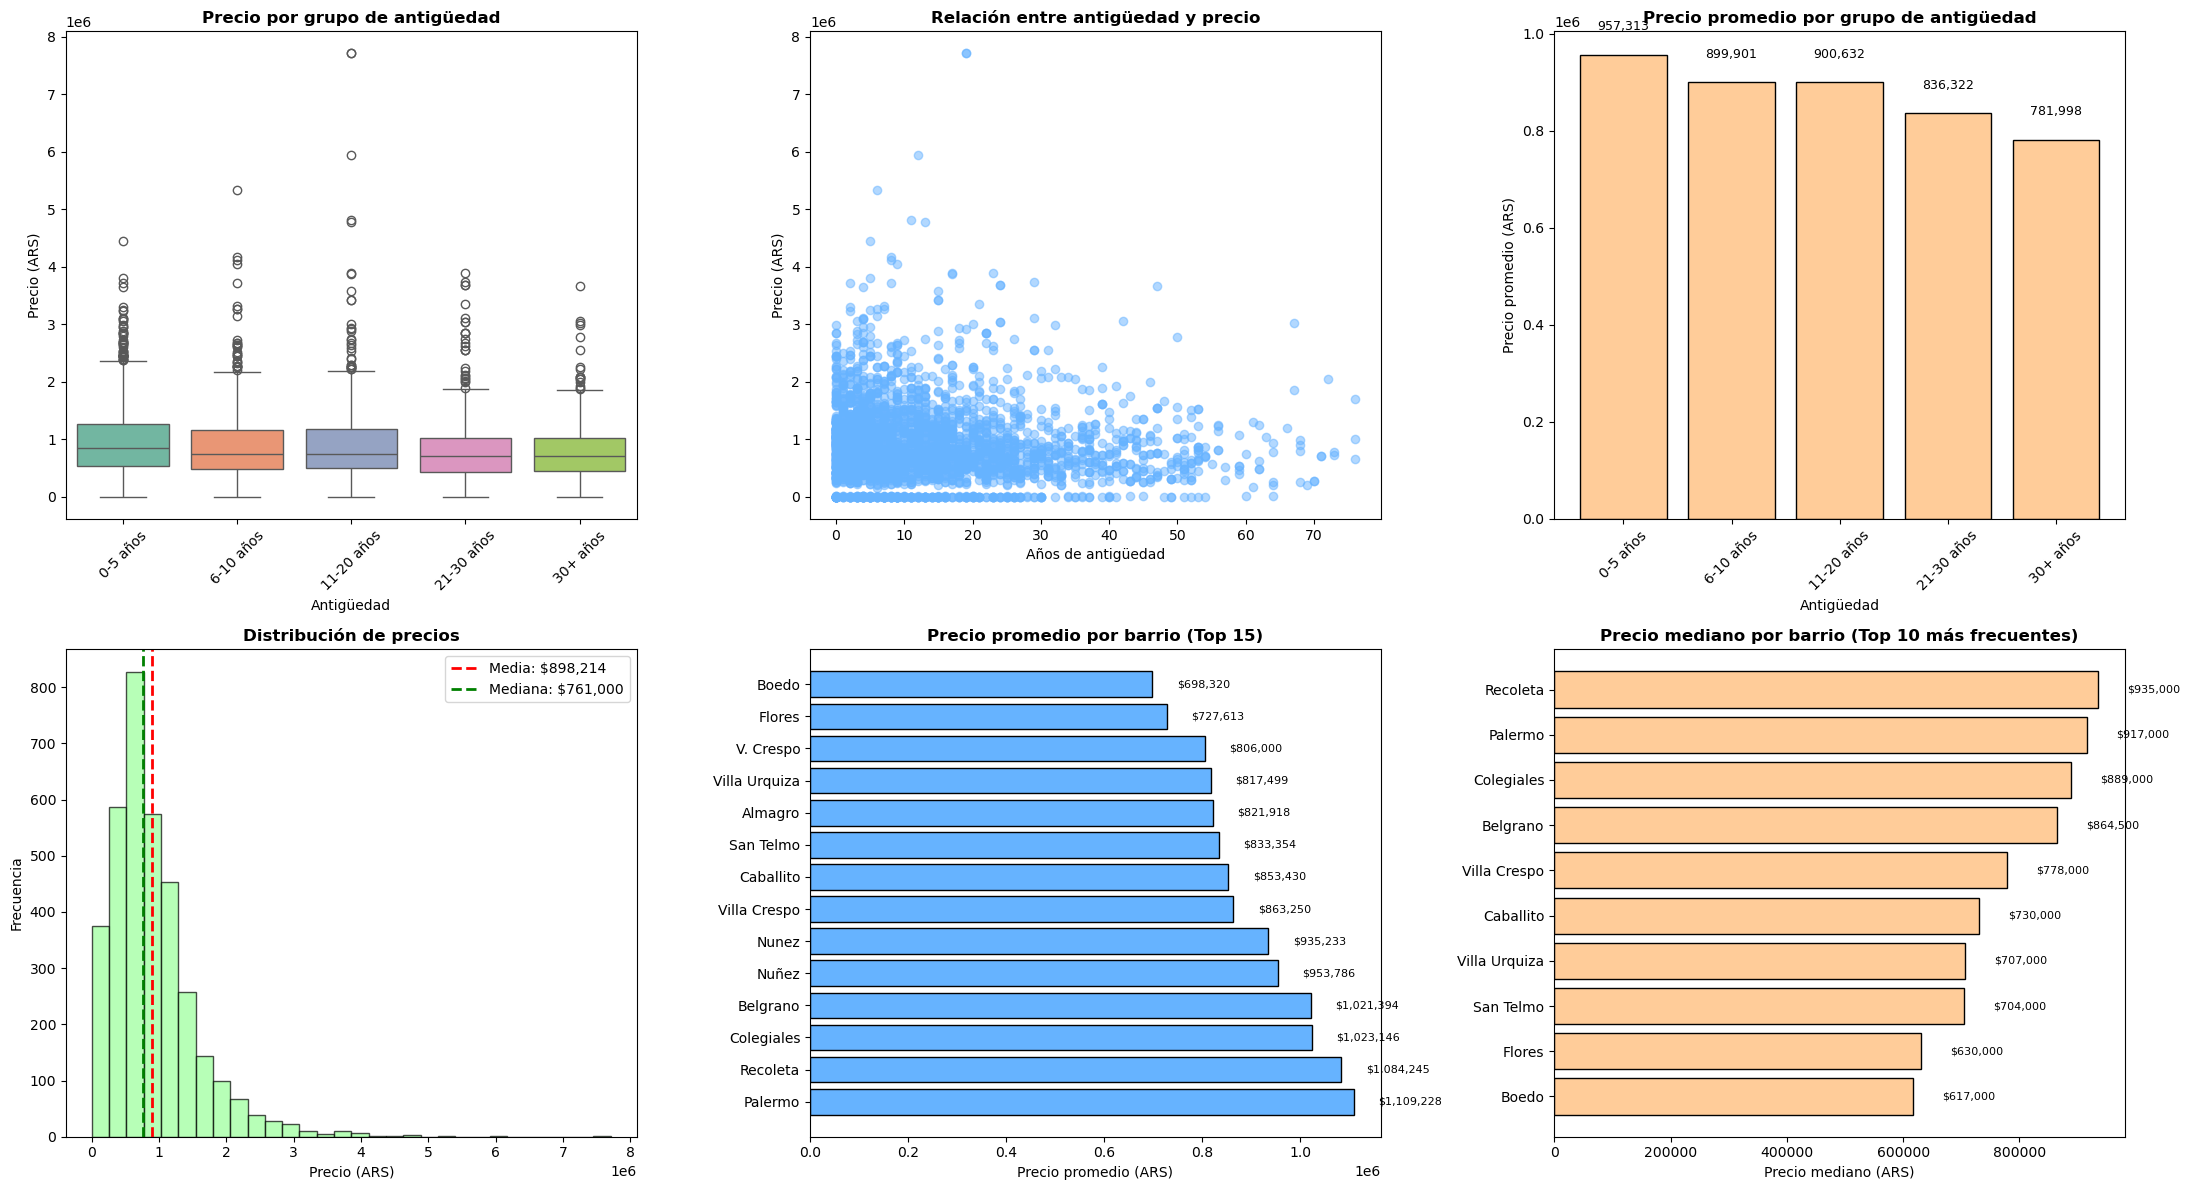


📊 ANÁLISIS COMPLETO DE PRECIO, ANTIGÜEDAD Y BARRIOS

📌 1. LIMPIEZA DE PRECIO:
------------------------------------------------------------
   • Total registros: 3,562
   • Con precio numérico: 3,516 (98.7%)
   • Con 'Consultar': 46 (1.3%)

   📋 Ejemplos de conversión de precio:
      • '1.267.000' → $1,267,000 ARS
      • '584.000' → $584,000 ARS
      • '252.000' → $252,000 ARS
      • '546.000' → $546,000 ARS
      • '337.000' → $337,000 ARS
      • '774.000' → $774,000 ARS
      • '1.324.000' → $1,324,000 ARS
      • 'USD 741' → $1,111,500 ARS
      • '1.513.000' → $1,513,000 ARS
      • '1.024.000' → $1,024,000 ARS

📌 2. PRECIO PROMEDIO POR BARRIO (Top 10):
------------------------------------------------------------
   1. Palermo: $1,109,228 ARS (n=285)
   2. Recoleta: $1,084,245 ARS (n=293)
   3. Colegiales: $1,023,146 ARS (n=289)
   4. Belgrano: $1,021,394 ARS (n=280)
   5. Nuñez: $953,786 ARS (n=261)
   6. Nunez: $935,233 ARS (n=10)
   7. Villa Crespo: $863,250 ARS (n=289)
   

In [6]:
# LIMPIEZA DE PRECIO
def clean_price(value):
    if pd.isna(value):
        return None
    value = str(value).strip()
    
    if value.lower() == 'consultar':
        return 'Consultar'
    
    if 'USD' in value.upper():
        match = re.search(r'(\d+(?:\.\d+)?)', value)
        if match:
            precio = float(match.group(1)) * 1500
            return None if precio > 20000000 else precio
    else:
        value_clean = value.replace('$', '').replace(' ', '').replace('.', '')
        match = re.search(r'(\d+)', value_clean)
        if match:
            precio = float(match.group(1))
            return None if precio > 20000000 else precio
    
    return None

df_a['precio_limpio'] = df_a['precio'].apply(clean_price)

# Solo eliminar registros con NaN (los None)
df_a = df_a[df_a['precio_limpio'].notna()].copy()


# LIMPIEZA DE ANTIGÜEDAD

def clean_age(value):
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    if 'estrenar' in value:
        return 0
    match = re.search(r'(\d+)', value)
    if match:
        return int(match.group(1))
    return None

df_a['antiguedad_valida'] = df_a['antiguedad'].apply(clean_age)

# Filtrar solo propiedades con antigüedad válida
df_con_antiguedad = df_a[df_a['antiguedad_valida'].notna()].copy()


# 3. CATEGORÍAS

def age_group(years):
    if years <= 5:
        return '0-5 años'
    elif years <= 10:
        return '6-10 años'
    elif years <= 20:
        return '11-20 años'
    elif years <= 30:
        return '21-30 años'
    else:
        return '30+ años'

df_con_antiguedad['grupo_antiguedad'] = df_con_antiguedad['antiguedad_valida'].apply(age_group)

# Normalizar nombres de barrios
df_a['zona_barrio'] = df_a['zona_barrio'].str.strip().str.title()
df_con_antiguedad['zona_barrio'] = df_con_antiguedad['zona_barrio'].str.strip().str.title()


#FILTRAR SOLO PRECIOS NUMÉRICOS PARA GRÁFICOS

# Crear columna auxiliar con precios numéricos (los 'Consultar' se convierten a NaN)
df_a['precio_num'] = pd.to_numeric(df_a['precio_limpio'], errors='coerce')
df_con_antiguedad['precio_num'] = pd.to_numeric(df_con_antiguedad['precio_limpio'], errors='coerce')


# GRÁFICOS

fig = plt.figure(figsize=(22, 12))

# Gráfico 1: Boxplot de precio por grupo de antigüedad
ax1 = fig.add_subplot(2, 3, 1)
df_box = df_con_antiguedad[df_con_antiguedad['precio_num'].notna()]
order = ['0-5 años', '6-10 años', '11-20 años', '21-30 años', '30+ años']
if len(df_box) > 0:
    sns.boxplot(data=df_box, x='grupo_antiguedad', y='precio_num', order=order, ax=ax1, palette='Set2')
    ax1.set_title('Precio por grupo de antigüedad', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Antigüedad')
    ax1.set_ylabel('Precio (ARS)')
    ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Scatter plot precio vs antigüedad
ax2 = fig.add_subplot(2, 3, 2)
df_scatter = df_con_antiguedad[df_con_antiguedad['precio_num'].notna()]
if len(df_scatter) > 0:
    ax2.scatter(df_scatter['antiguedad_valida'], df_scatter['precio_num'], alpha=0.5, color='#66b3ff')
    ax2.set_xlabel('Años de antigüedad')
    ax2.set_ylabel('Precio (ARS)')
    ax2.set_title('Relación entre antigüedad y precio', fontsize=12, fontweight='bold')

# Gráfico 3: Barras - Precio promedio por antigüedad
ax3 = fig.add_subplot(2, 3, 3)
if len(df_box) > 0:
    precio_promedio_edad = df_box.groupby('grupo_antiguedad')['precio_num'].mean().reindex(order)
    ax3.bar(precio_promedio_edad.index, precio_promedio_edad.values, color='#ffcc99', edgecolor='black')
    ax3.set_title('Precio promedio por grupo de antigüedad', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Antigüedad')
    ax3.set_ylabel('Precio promedio (ARS)')
    ax3.tick_params(axis='x', rotation=45)
    for i, v in enumerate(precio_promedio_edad.values):
        if not pd.isna(v):
            ax3.text(i, v + 50000, f'{v:,.0f}', ha='center', fontsize=9)

# Gráfico 4: Histograma de precios
ax4 = fig.add_subplot(2, 3, 4)
precios_numericos = df_a[df_a['precio_num'].notna()]['precio_num']
if len(precios_numericos) > 0:
    ax4.hist(precios_numericos, bins=30, color='#99ff99', edgecolor='black', alpha=0.7)
    ax4.axvline(precios_numericos.mean(), color='red', linestyle='dashed', linewidth=2, 
                label=f'Media: ${precios_numericos.mean():,.0f}')
    ax4.axvline(precios_numericos.median(), color='green', linestyle='dashed', linewidth=2,
                label=f'Mediana: ${precios_numericos.median():,.0f}')
    ax4.set_xlabel('Precio (ARS)')
    ax4.set_ylabel('Frecuencia')
    ax4.set_title('Distribución de precios', fontsize=12, fontweight='bold')
    ax4.legend()

# Gráfico 5: Precio promedio por barrio (Top 15)
ax5 = fig.add_subplot(2, 3, 5)
df_precio_barrio = df_a[df_a['precio_num'].notna()]
precio_por_barrio = df_precio_barrio.groupby('zona_barrio')['precio_num'].mean().sort_values(ascending=False).head(15)
if len(precio_por_barrio) > 0:
    ax5.barh(precio_por_barrio.index, precio_por_barrio.values, color='#66b3ff', edgecolor='black')
    ax5.set_xlabel('Precio promedio (ARS)')
    ax5.set_title('Precio promedio por barrio (Top 15)', fontsize=12, fontweight='bold')
    for i, v in enumerate(precio_por_barrio.values):
        ax5.text(v + 50000, i, f'${v:,.0f}', va='center', fontsize=8)

# Gráfico 6: Precio mediano por barrio (Top 10 más frecuentes)
ax6 = fig.add_subplot(2, 3, 6)
top10_barrios = df_precio_barrio['zona_barrio'].value_counts().head(10).index
df_top10 = df_precio_barrio[df_precio_barrio['zona_barrio'].isin(top10_barrios)]
precio_mediana_barrio = df_top10.groupby('zona_barrio')['precio_num'].median().sort_values()
if len(precio_mediana_barrio) > 0:
    ax6.barh(precio_mediana_barrio.index, precio_mediana_barrio.values, color='#ffcc99', edgecolor='black')
    ax6.set_xlabel('Precio mediano (ARS)')
    ax6.set_title('Precio mediano por barrio (Top 10 más frecuentes)', fontsize=12, fontweight='bold')
    for i, v in enumerate(precio_mediana_barrio.values):
        ax6.text(v + 50000, i, f'${v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# =====================================================
# RESULTADOS EN CONSOLA
# =====================================================
print("\n" + "="*80)
print("📊 ANÁLISIS COMPLETO DE PRECIO, ANTIGÜEDAD Y BARRIOS")
print("="*80)

print("\n📌 1. LIMPIEZA DE PRECIO:")
print("-"*60)
total_registros = len(df_a)
con_precio_num = df_a['precio_num'].notna().sum()
con_precio_consultar = (df_a['precio_limpio'] == 'Consultar').sum()
print(f"   • Total registros: {total_registros:,}")
print(f"   • Con precio numérico: {con_precio_num:,} ({con_precio_num/total_registros*100:.1f}%)")
print(f"   • Con 'Consultar': {con_precio_consultar:,} ({con_precio_consultar/total_registros*100:.1f}%)")

print("\n   📋 Ejemplos de conversión de precio:")
ejemplos = df_a[df_a['precio_num'].notna()][['precio', 'precio_num']].head(10)
for idx, row in ejemplos.iterrows():
    print(f"      • '{row['precio']}' → ${row['precio_num']:,.0f} ARS")

print("\n📌 2. PRECIO PROMEDIO POR BARRIO (Top 10):")
print("-"*60)
for i, (barrio, precio) in enumerate(precio_por_barrio.head(10).items(), 1):
    count = df_precio_barrio[df_precio_barrio['zona_barrio'] == barrio].shape[0]
    print(f"   {i}. {barrio}: ${precio:,.0f} ARS (n={count})")

print("\n📌 3. BARRIOS CON MÁS PROPIEDADES (Top 10):")
print("-"*60)
barrios_count = df_a['zona_barrio'].value_counts().head(10)
for i, (barrio, count) in enumerate(barrios_count.items(), 1):
    print(f"   {i}. {barrio}: {count:,} propiedades")

print("\n📌 4. PRECIO PROMEDIO POR ANTIGÜEDAD:")
print("-"*60)
if len(df_box) > 0:
    for grupo in order:
        if grupo in precio_promedio_edad.index:
            promedio = precio_promedio_edad[grupo]
            count = df_box[df_box['grupo_antiguedad'] == grupo].shape[0]
            if not pd.isna(promedio):
                print(f"   • {grupo}: ${promedio:,.0f} ARS (n={count})")

print("\n📌 5. ESTADÍSTICAS GENERALES DE PRECIO:")
print("-"*60)
if len(precios_numericos) > 0:
    print(f"   • Media: ${precios_numericos.mean():,.0f} ARS")
    print(f"   • Mediana: ${precios_numericos.median():,.0f} ARS")
    print(f"   • Mínimo: ${precios_numericos.min():,.0f} ARS")
    print(f"   • Máximo: ${precios_numericos.max():,.0f} ARS")

print("\n" + "="*80)

NOTA: Se elimino aquellas propiedades que tenian los años superiores a 20M que era un desfasaje muy alto de los datos

In [7]:
# EXPENSAS → binaria

df1['expensas'] = pd.to_numeric(df1['expensas'], errors='coerce').fillna(0)
df1['expensas'] = df1['expensas'].apply(lambda x: 1 if x > 0 else 0)

# NORMALIZACIÓN DE TEXTO

def normalize_text(text):
    if pd.isna(text):
        return text
    return str(text).strip().title()

df1['zona_barrio'] = df1['zona_barrio'].apply(normalize_text)
df1['tipo'] = df1['tipo'].apply(normalize_text)


# SUPERFICIES

def clean_surface(value):
    if pd.isna(value):
        return None
    
    value = str(value).strip()
    match = re.search(r'(\d+(?:\.\d+)?)', value)
    
    if match:
        return float(match.group(1))
    
    return None

df1['superficie_total'] = df1['superficie_total'].apply(clean_surface)
df1['superficie_cubierta'] = df1['superficie_cubierta'].apply(clean_surface)

# Completar cubierta con total si falta
df1['superficie_cubierta'] = df1['superficie_cubierta'].fillna(df1['superficie_total'])

# BAÑOS / AMBIENTES

df1['banios'] = (
    df1['banios']
    .fillna(1)
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .fillna(1)
    .astype(int)
)

col = df1['ambientes'].astype(str).str.strip().str.lower()

# Detectar monoambientes
mono_mask = col.str.contains('monoambiente', na=False)

# Extraer números
ambientes = col.str.extract(r'(\d+)')[0].astype(float)

# Reemplazar monoambiente → 1
ambientes[mono_mask] = 1

# Pasar a entero nullable
df1['ambientes'] = ambientes.astype('Int64')

# Dormitorios = ambientes - 1
df1['dormitorios'] = df1['ambientes'] - 1

# Monoambiente → dormitorios = 0
df1.loc[mono_mask, 'dormitorios'] = 0

# Evitar negativos
df1['dormitorios'] = df1['dormitorios'].clip(lower=0)



# ANTIGÜEDAD

def clean_age(value):
    if pd.isna(value):
        return None
    
    value = str(value).strip().lower()
    
    if 'estrenar' in value:
        return 0
    
    match = re.search(r'(\d+)', value)
    if match:
        return int(match.group(1))
    
    return None

df1['antiguedad'] = df1['antiguedad'].apply(clean_age)

# ❗ eliminar filas sin antigüedad
df1 = df1[df1['antiguedad'].notna()].copy()



# PRECIO

def clean_price(value):
    if pd.isna(value):
        return None
    
    value = str(value).strip()
    
    # detectar "consultar" sin importar mayúsculas/minúsculas
    if 'consultar' in value.lower():
        return None
    
    # caso USD
    if 'usd' in value.lower():
        match = re.search(r'(\d+(?:\.\d+)?)', value)
        if match:
            precio = float(match.group(1)) * 1500
            return None if precio > 20000000 else precio
    
    # caso moneda local
    value_clean = value.replace('$', '').replace(' ', '').replace('.', '')
    match = re.search(r'(\d+)', value_clean)
    
    if match:
        precio = float(match.group(1))
        return None if precio > 20000000 else precio
    
    return None

df1['precio'] = df1['precio'].apply(clean_price)

# eliminar precios inválidos
df1 = df1[df1['precio'].notna()].copy()

df1['amenities'] = (df1['amenities'].astype(str).str.strip().str.lower() == 'pileta').astype(int)


In [8]:
df1.head(15)

,id_aviso,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,banios,antiguedad,cochera,balcon,amenities,latitud,longitud,fecha_publicacion
0,A-700480,Belgrano,Departamento,1267000.0,1,75.0,75.0,4,3,2,4.0,Sí,Sí,0,-34.549646421652646,-58.462834001141694,04/01/2025
1,A-220016,Almagro,Departamento,584000.0,1,39.0,39.0,2,1,1,6.0,No,No,0,-34.60873815826056,-58.43909947532191,15/01/2024
2,A-492142,Flores,Departamento,252000.0,0,35.0,35.0,2,1,1,23.0,Sí,No,0,"-34,62205081312381",-58.45626733855754,07/03/2024
3,A-675147,Belgrano,Ph,546000.0,0,38.0,38.0,2,1,1,0.0,No,No,1,-34.574756771995716,-58.463757544997684,04/12/2024
4,A-307536,Villa Urquiza,Departamento,337000.0,1,33.0,33.0,1,0,1,2.0,No,Sí,0,-34.55428879305003,-58.4866156408398,25/02/2024
5,A-971306,Boedo,Departamento,774000.0,1,76.0,76.0,3,2,1,24.0,Sí,Sí,0,-34.62344873911467,-58.40810592330541,23/11/2024
6,A-247481,Palermo,Ph,1324000.0,0,66.0,66.0,2,1,1,16.0,Sí,Sí,0,-34.586347936612235,-58.41099567971239,29/06/2024
7,A-148608,Palermo,Departamento,1111500.0,1,37.0,37.0,1,0,1,0.0,No,No,0,-34.5582681308029,-58.42566948108769,13/06/2025
8,A-397070,Recoleta,Casa,1513000.0,0,60.0,60.0,3,2,1,5.0,Sí,No,0,-34.59633012083062,-58.39006811756547,26/06/2024
9,A-558506,Flores,Departamento,1024000.0,0,102.0,102.0,6,5,4,13.0,No,Sí,0,-34.646815062261375,-58.45992555502545,28/04/2025


In [9]:
df2 = pd.read_csv(r"listings_plataforma_B.csv",)
df2_raw = df2.copy()
df2.drop(["category_l1", "category_l2"], axis=1, inplace=True)
df2.rename(columns={"neighborhood": "zona_barrio","id_aviso": "listing_id","property_type": "tipo","superficie_total": "total_area_m2","superficie_cubierta": "covered_area_m2","rooms": "ambientes",
                     "has_pool": "amenities", "age_years":"antiguedad","has_garage":"cochera","has_balcony":"balcon","bedrooms":"dormitorios", "bathrooms":"banios","lat":"latitud", "lng":"longitud",
                     "total_area_m2":"superficie_total","covered_area_m2":"superficie_cubierta","price_ars":"precio"}, inplace=True)
df2.head()

,listing_id,tipo,zona_barrio,precio,superficie_cubierta,superficie_total,ambientes,dormitorios,banios,antiguedad,cochera,balcon,amenities,latitud,longitud,created_at
0,MLA757902287,DEPARTAMENTO,Palermo,713000.0,50.0,50.0,NaN,2.0,1.0,14.0,False,True,False,-34.549232,-58.425510,2025-01-18 00:00:00
1,MLA371511639,DEPARTAMENTO,Almagro,724000.0,50.0,50.0,2.0,1.0,1.0,NaN,False,False,False,-34.586467,-58.439921,2024-08-08 00:00:00
2,MLA154908801,DEPARTAMENTO,Almagro,348000.0,42.0,NaN,2.0,NaN,1.0,13.0,True,False,False,-34.607493,-58.417589,2024-08-18 00:00:00
3,MLA403100436,DEPARTAMENTO,Villa Urquiza,1217000.0,66.0,66.0,2.0,1.0,1.0,2.0,True,True,False,-34.567514,-58.487023,2024-11-03 00:00:00
4,MLA346000441,CASA,Palermo,1121000.0,86.0,164.0,3.0,2.0,1.0,1.0,True,False,True,-34.589963,-58.444575,2025-03-22 00:00:00


In [10]:
def normalize_text(text):
    if pd.isna(text):
        return text
    return str(text).strip().title()

df2['zona_barrio'] = df2['zona_barrio'].apply(normalize_text)
df2['tipo'] = df2['tipo'].apply(normalize_text)



# SUPERFICIES

def extract_number(series):
    return (
        series.astype(str)
        .str.extract(r'(\d+(?:\.\d+)?)')[0]
        .astype(float)
    )

# 1. Limpieza inicial
df2['superficie_total'] = extract_number(df2['superficie_total'])
df2['superficie_cubierta'] = extract_number(df2['superficie_cubierta'])

# 2. Si falta total → usar cubierta
df2['superficie_total'] = df2['superficie_total'].fillna(df2['superficie_cubierta'])

# 3. Si falta cubierta → borrar fila (regla estricta)
df2 = df2.dropna(subset=['superficie_cubierta'])

# 4. Si aún falta total → borrar fila
df2 = df2.dropna(subset=['superficie_total'])

# 5. OPCIONAL (recomendado): corregir inconsistencias en vez de borrar
df2.loc[
    df2['superficie_cubierta'] > df2['superficie_total'],
    'superficie_cubierta'
] = df2['superficie_total']



# BAÑOS / AMBIENTES / DORMITORIOS


df2['banios'] = (df2['banios'].fillna(1).astype(str).str.extract(r'(\d+)')[0].fillna(1).astype(int))

# AMBIENTES
df2['ambientes'] = (
    df2['ambientes']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# DORMITORIOS
df2['dormitorios'] = (
    df2['dormitorios']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)


# REGLAS DE CONSISTENCIA


# Monoambiente → 0 dormitorios
df2.loc[df2['ambientes'] == 1, 'dormitorios'] = 0

# Si falta ambientes pero hay dormitorios → ambientes = dormitorios + 1
df2.loc[df2['ambientes'].isna() & df2['dormitorios'].notna(), 'ambientes'] = (
    df2['dormitorios'] + 1
)

# Si falta dormitorios pero hay ambientes → dormitorios = ambientes - 1
df2.loc[df2['dormitorios'].isna() & df2['ambientes'].notna(), 'dormitorios'] = (
    df2['ambientes'] - 1
)

# Evitar negativos
df2['dormitorios'] = df2['dormitorios'].clip(lower=0)

# Convertir a enteros nullable
df2['ambientes'] = df2['ambientes'].astype('Int64')
df2['dormitorios'] = df2['dormitorios'].astype('Int64')

# ANTIGÜEDAD


def clean_age(value):
    if pd.isna(value):
        return None
    
    value = str(value).strip().lower()
    
    if 'estrenar' in value:
        return 0
    
    match = re.search(r'(\d+)', value)
    if match:
        return int(match.group(1))
    
    return None

df2['antiguedad'] = df2['antiguedad'].apply(clean_age)

df2 = df2[df2['antiguedad'].notna()].copy()

# PRECIO

def clean_price(value):
    if pd.isna(value):
        return None
    
    value = str(value).strip()
    
    if 'consultar' in value.lower():
        return None
    
    if 'usd' in value.lower():
        match = re.search(r'(\d+(?:\.\d+)?)', value)
        if match:
            precio = float(match.group(1)) * 1500
            return None if precio > 20000000 else precio
    
    value_clean = value.replace('$', '').replace(' ', '').replace('.', '')
    match = re.search(r'(\d+)', value_clean)
    
    if match:
        precio = float(match.group(1))
        return None if precio > 20000000 else precio
    
    return None

df2['precio'] = df2['precio'].apply(clean_price)

df2 = df2[df2['precio'].notna()].copy()

In [11]:
df2.tipo.value_counts()

tipo
Departamento    1751
Ph               271
Casa             103
Name: count, dtype: int64

In [12]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2125 entries, 0 to 3638
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           2125 non-null   object 
 1   tipo                 2125 non-null   object 
 2   zona_barrio          2125 non-null   object 
 3   precio               2125 non-null   float64
 4   superficie_cubierta  2125 non-null   float64
 5   superficie_total     2125 non-null   float64
 6   ambientes            2122 non-null   Int64  
 7   dormitorios          2122 non-null   Int64  
 8   banios               2125 non-null   int32  
 9   antiguedad           2125 non-null   float64
 10  cochera              2125 non-null   bool   
 11  balcon               2125 non-null   bool   
 12  amenities            2125 non-null   bool   
 13  latitud              2125 non-null   float64
 14  longitud             2125 non-null   float64
 15  created_at           2125 non-null   object

In [13]:
df3 = pd.read_csv(r"listings_plataforma_C.csv")
df3_raw = df3.copy()
df3 = df3.rename(columns={'codigo': 'id_aviso', 'tipo_inmueble': 'tipo', 'barrio': 'zona_barrio', 'precio_publicado': 'precio', 'coordenadas': 'coordenadas_raw', 'publicado': 'fecha_publicacion'
                })
df3.drop(["operacion", ], axis=1, inplace=True)
df3.head()

,id_aviso,tipo,zona_barrio,precio,superficie,descripcion,coordenadas_raw,fecha_publicacion
0,AP-64391,ph,Villa Urquiza,$678.000/mes,55,2 ambientes. 1 dorm. 1 baños. pileta,"-34.57599599633878,-58.47863988110282",10-03-2024
1,AP-82260,ph,Colegiales,$700.000/mes,50,2 ambientes. 1 dorm. 1 baños. balcón. 11 años,"-34.582690398643514,-58.4524965859866",30-11-2024
2,AP-66765,departamento,Caballito,$719.000/mes,41,3 ambientes. 2 baños. 11 años,NaN,28-07-2024
3,AP-42570,departamento,Villa Crespo,$1.391.000/mes,58,3 ambientes. 2 dorm. con cochera. 4 años,NaN,31-12-2024
4,AP-64652,departamento,Recoleta,Consultar,53,3 ambientes. 2 dorm. 2 baños. con cochera. 18 ...,NaN,08-01-2025


In [14]:
df3.isna().sum()

id_aviso                0
tipo                    0
zona_barrio             0
precio                  0
superficie            186
descripcion            17
coordenadas_raw      1464
fecha_publicacion       0
dtype: int64

In [15]:
df3.shape

(3699, 8)

In [16]:
def parse_coordinates(coord_str):
    if pd.isna(coord_str):
        return None, None
    
    coord_str = str(coord_str).strip()
    
    # eliminar casos vacíos tipo "" o "   "
    if coord_str == "":
        return None, None
    
    coord_str = coord_str.replace('"', '').replace("'", "")
    
    match = re.search(r'(-?\d+\.\d+),\s*(-?\d+\.\d+)', coord_str)
    
    if match:
        return float(match.group(1)), float(match.group(2))
    
    return None, None


# eliminar coordenadas vacías ANTES de procesar
df3 = df3[df3['coordenadas_raw'].notna()].copy()
df3 = df3[df3['coordenadas_raw'].astype(str).str.strip() != ""].copy()


# parseo
df3[['latitud', 'longitud']] = df3['coordenadas_raw'].apply(
    lambda x: pd.Series(parse_coordinates(x))
)

# eliminar columna original
df3 = df3.drop(columns=['coordenadas_raw'])

In [17]:
df3.head()

,id_aviso,tipo,zona_barrio,precio,superficie,descripcion,fecha_publicacion,latitud,longitud
0,AP-64391,ph,Villa Urquiza,$678.000/mes,55,2 ambientes. 1 dorm. 1 baños. pileta,10-03-2024,-34.575996,-58.478640
1,AP-82260,ph,Colegiales,$700.000/mes,50,2 ambientes. 1 dorm. 1 baños. balcón. 11 años,30-11-2024,-34.582690,-58.452497
6,AP-11701,departamento,Palermo,$713.000/mes,50,2 dorm. 1 baños. balcón,24-09-2024,-34.549232,-58.425510
7,AP-60779,departamento,Almagro,$1.284.000/mes,72,3 ambientes. 2 dorm. 1 baños,27-04-2025,-34.616118,-58.410934
11,AP-33162,departamento,San Telmo,$586.000/mes,49,1 dorm. 1 baños. balcón,11-01-2024,-34.610666,-58.389325


In [18]:
def extract_rooms(desc):
    if pd.isna(desc):
        return None
    match = re.search(r'(\d+)\s*ambientes', str(desc).lower())
    return int(match.group(1)) if match else None


def extract_bedrooms(desc):
    if pd.isna(desc):
        return None
    
    text = str(desc).lower()
    
    match = re.search(r'(\d+)\s*dorm', text)
    if match:
        return int(match.group(1))
    
    rooms = extract_rooms(desc)
    if rooms and rooms >= 2:
        return rooms - 1
    
    return 0 if rooms == 1 else None


def extract_bathrooms(desc):
    if pd.isna(desc):
        return 1  # por defecto
    match = re.search(r'(\d+)\s*baños?', str(desc).lower())
    return int(match.group(1)) if match else 1


def extract_age(desc):
    if pd.isna(desc):
        return None
    
    text = str(desc).lower()
    
    if 'a estrenar' in text:
        return 'A estrenar'
    
    match = re.search(r'(\d+)\s*años?', text)
    if match:
        return f"{match.group(1)} años"
    
    return None


def extract_garage(desc):
    if pd.isna(desc):
        return 0
    text = str(desc).lower()
    return 1 if 'con cochera' in text else 0


def extract_balcony(desc):
    if pd.isna(desc):
        return 0
    text = str(desc).lower()
    return 1 if 'balcón' in text or 'balcon' in text else 0


def extract_pool(desc):
    if pd.isna(desc):
        return 0
    text = str(desc).lower()
    return 1 if 'pileta' in text else 0


# =========================
# APLICACIÓN
# =========================

print(f"\n📌 Extrayendo datos desde descripción...")

df3['ambientes'] = df3['descripcion'].apply(extract_rooms)
df3['dormitorios'] = df3['descripcion'].apply(extract_bedrooms)
df3['banios'] = df3['descripcion'].apply(extract_bathrooms)
df3['antiguedad'] = df3['descripcion'].apply(extract_age)
df3['cochera'] = df3['descripcion'].apply(extract_garage)
df3['balcon'] = df3['descripcion'].apply(extract_balcony)
df3['pileta'] = df3['descripcion'].apply(extract_pool)

print(f"   • Ambientes extraídos: {df3['ambientes'].notna().sum():,} registros")
print(f"   • Dormitorios extraídos: {df3['dormitorios'].notna().sum():,} registros")
print(f"   • Baños extraídos: {df3['banios'].notna().sum():,} registros (default 1)")
print(f"   • Antigüedad extraída: {df3['antiguedad'].notna().sum():,} registros")
print(f"   • Cochera: {df3['cochera'].sum():,} tienen (1), {len(df3) - df3['cochera'].sum():,} no tienen (0)")
print(f"   • Balcón: {df3['balcon'].sum():,} tienen (1), {len(df3) - df3['balcon'].sum():,} no tienen (0)")
print(f"   • Pileta: {df3['pileta'].sum():,} tienen (1), {len(df3) - df3['pileta'].sum():,} no tienen (0)")


# eliminar descripción original
df3 = df3.drop(columns=['descripcion'])


📌 Extrayendo datos desde descripción...
   • Ambientes extraídos: 1,779 registros
   • Dormitorios extraídos: 2,110 registros
   • Baños extraídos: 2,235 registros (default 1)
   • Antigüedad extraída: 1,174 registros
   • Cochera: 579 tienen (1), 1,656 no tienen (0)
   • Balcón: 719 tienen (1), 1,516 no tienen (0)
   • Pileta: 227 tienen (1), 2,008 no tienen (0)


In [19]:
def clean_price(value):
    if pd.isna(value):
        return None
    
    value = str(value).strip().lower()
    
    # consultar → NaN
    if 'consultar' in value:
        return None
    
    # quitar símbolos y texto
    value = (
        value
        .replace('$', '')
        .replace('/mes', '')
        .replace('usd', '')
        .replace('ars', '')
        .strip()
    )
    
    # dejar solo números y puntos/comas
    value = re.sub(r'[^\d.]', '', value)
    
    # eliminar separadores de miles (puntos mal usados)
    value = value.replace('.', '')
    
    # extraer número final
    match = re.search(r'\d+', value)
    
    if match:
        precio = float(match.group(0))
        return None if precio > 20000000 else precio
    
    return None


df3['precio'] = df3['precio'].apply(clean_price)

# eliminar nulos
df3 = df3[df3['precio'].notna()].copy()

# asegurar tipo numérico
df3['precio'] = df3['precio'].astype(float)

def normalize_text(text):
    if pd.isna(text):
        return text
    return str(text).strip().title()

df3['zona_barrio'] = df3['zona_barrio'].apply(normalize_text)
df3['tipo'] = df3['tipo'].apply(normalize_text)


In [20]:
# Pasar todo a string y minúsculas
col = df3['antiguedad'].astype(str).str.strip().str.lower()

# Crear nueva columna
df3['antiguedad'] = (
    col
    .str.extract(r'(\d+)')          # extrae números
    .astype(float)                  # permite NaN
)

# Reemplazar "a estrenar" por 0
df3.loc[col.str.contains('a estrenar', na=False), 'antiguedad'] = 0

# Eliminar filas con NaN
df3 = df3.dropna(subset=['antiguedad'])

# Convertir a int si querés
df3['antiguedad'] = df3['antiguedad'].astype(int)

df3['banios'] = df3['banios'].fillna(1)

In [21]:
# asegurar formato numérico
df3['ambientes'] = pd.to_numeric(df3['ambientes'], errors='coerce')
df3['dormitorios'] = pd.to_numeric(df3['dormitorios'], errors='coerce')

# 1. Monoambiente → 0 dormitorios
df3.loc[df3['ambientes'] == 1, 'dormitorios'] = 0

# 2. Si falta dormitorios y hay ambientes ≥ 2 → dorm = amb - 1
df3.loc[
    (df3['dormitorios'].isna()) & (df3['ambientes'] >= 2),
    'dormitorios'
] = df3['ambientes'] - 1

# 3. Si falta ambientes y hay dormitorios ≥ 1 → amb = dorm + 1
df3.loc[
    (df3['ambientes'].isna()) & (df3['dormitorios'] >= 1),
    'ambientes'
] = df3['dormitorios'] + 1

# 4. Evitar negativos
df3['dormitorios'] = df3['dormitorios'].clip(lower=0)

# 5. Convertir a enteros nullable
df3['ambientes'] = df3['ambientes'].astype('Int64')
df3['dormitorios'] = df3['dormitorios'].astype('Int64')

df3 = df3[df3['superficie'].notna()].copy()
df3 = df3[df3['dormitorios'].notna()].copy()

In [22]:
df3.head()

,id_aviso,tipo,zona_barrio,precio,superficie,fecha_publicacion,latitud,longitud,ambientes,dormitorios,banios,antiguedad,cochera,balcon,pileta
1,AP-82260,Ph,Colegiales,700000.0,50,30-11-2024,-34.582690,-58.452497,2,1,1,11,0,1,0
24,AP-14309,Departamento,Almagro,873000.0,58,05-03-2025,-34.639285,-58.411342,3,2,1,41,0,0,0
26,AP-97135,Departamento,Almagro,651000.0,40,29-03-2025,-34.610274,-58.436579,2,1,1,16,0,0,0
28,AP-89383,Ph,Nuñez,1251000.0,71,18-09-2024,-34.557013,-58.466404,2,1,1,11,1,0,0
29,AP-27707,Departamento,Caballito,627000.0,53,03-10-2024,-34.616155,-58.446939,2,1,1,33,0,0,0


### Union de los 3 datasets

Luego de analizar todos los datasets provenientes de distintas fuentes, aplicando diversos procesos estadísticos y realizando gráficos exploratorios para entender el comportamiento de los datos, se obtuvieron las siguientes conclusiones y decisiones de limpieza:

En primer lugar, se analizaron las expensas, evaluando su distribución y su impacto en el precio del alquiler. En algunos casos, incluso superaban el valor del alquiler, lo que podría sugerir que se trataba de expensas extraordinarias; sin embargo, no era así. Al comparar con otros datasets, se observó que esta variable no estaba presente de manera consistente. Además, presentaba cerca de un 50% de datos faltantes, por lo que se decidió eliminarla.

Respecto a la variable de antigüedad (años), no se detectaron valores inconsistentes o atípicos. Por este motivo, se decidió conservarla como variable relevante. Sin embargo, se eliminaron aquellos registros que no contaban con este dato, dado que influye directamente en el precio del alquiler.

En cuanto a los datos faltantes, la variable “amenities” (por ejemplo, presencia de pileta) está presente en los tres datasets, por lo que se conservó. En los casos faltantes, se imputó con valor 0 (ausencia). Las variables cochera y balcón también se conservaron, ya que estaban disponibles en todas las fuentes.

Para las variables ambientes, baños y dormitorios, se aplicaron reglas de imputación. Si una propiedad no informaba la cantidad de baños, se asumió por defecto que posee uno, dado que toda construcción lo incluye. Para ambientes faltantes, se utilizó la fórmula: ambientes = dormitorios + 1; en caso de que dormitorios fuera 0, se asignó 1 ambiente. De manera inversa, para estimar dormitorios se utilizó: dormitorios = ambientes - 1. En los casos donde faltaban tanto ambientes como dormitorios, se eliminaron los registros como parte del proceso de limpieza.

En relación al precio, se detectó que los valores estaban expresados tanto en USD como en pesos. Para los precios en USD, se utilizó un tipo de cambio fijo de referencia de 1500, con la posibilidad de actualizarlo en el futuro mediante una API (por ejemplo, “dólar hoy”) con frecuencia diaria. Para los valores en pesos, se conservaron, pero se eliminaron aquellos registros con precios superiores a 20 millones e inferiores a 300 mil, en base a análisis estadísticos y visualizaciones previas.

En las variables tipo y zona/barrio, se unificaron criterios de escritura (mayúsculas y minúsculas) para evitar inconsistencias.

Respecto a la antigüedad, los registros que indicaban “a estrenar” se reemplazaron por valor 0. Aquellos sin información fueron eliminados, ya que esta variable es relevante en el análisis del precio junto con la ubicación.

En relación a las superficies, se aplicó un proceso de limpieza y consistencia entre superficie total y superficie cubierta. Ambos campos fueron estandarizados a valores numéricos. Cuando la superficie total no estaba informada, se imputó utilizando la superficie cubierta. En cambio, los registros sin superficie cubierta fueron eliminados por considerarse incompletos. Adicionalmente, en los casos donde la superficie cubierta era mayor a la superficie total, se corrigieron los valores ajustando la superficie cubierta para que no exceda la total, garantizando coherencia física de los datos. Finalmente, se decidió conservar únicamente la superficie total como variable representativa del tamaño del inmueble, descartando la superficie cubierta por su baja consistencia en el dataset.

Por último, se eliminaron todos los registros que no contaban con información de latitud y longitud, ya que la ubicación geográfica es una variable clave para el análisis espacial y la estimación del precio de los inmuebles.
Asi a quedado el dataset final:
| Variable            | Descripción                                      |
|---------------------|--------------------------------------------------|
| id_aviso            | Identificador único del aviso                    |
| tipo                | Tipo de propiedad                                |
| zona_barrio         | Barrio o zona donde se ubica el inmueble         |
| precio              | Precio del alquiler                              |
| superficie          | Superficie total del inmueble                    |
| ambientes           | Cantidad de ambientes                            |
| dormitorios         | Cantidad de dormitorios                          |
| banios              | Cantidad de baños                                |
| antiguedad          | Antigüedad del inmueble                          |
| cochera             | Indica si posee cochera (1: sí, 0: no)           |
| balcon              | Indica si posee balcón (1: sí, 0: no)            |
| pileta              | Indica si posee pileta (1: sí, 0: no)            |
| fecha_publicacion   | Fecha de publicación del aviso                   |
| latitud             | Coordenada geográfica (latitud)                  |
| longitud            | Coordenada geográfica (longitud)                 |



In [23]:
Final_columns = ['id_aviso', 'tipo', 'zona_barrio', 'precio', 'superficie', 'ambientes', 'dormitorios', 'banios', 'antiguedad',  'cochera', 'balcon', 'pileta',
    'fecha_publicacion', 'latitud', 'longitud']

In [24]:
def estandarizar_dataframe(df, rename_map, drop_cols=None):
    df = df.copy()

    # renombrar columnas
    df = df.rename(columns=rename_map)

    # eliminar columnas innecesarias
    if drop_cols:
        df = df.drop(columns=drop_cols, errors='ignore')

    # asegurar todas las columnas del esquema
    for col in Final_columns:
        if col not in df.columns:
            df[col] = pd.NA

    # quedarnos solo con las columnas finales y en orden
    df = df[Final_columns]

    return df

In [25]:
df1_clean = estandarizar_dataframe(
    df1,
    rename_map={
        'superficie_total': 'superficie',
        'amenities': 'pileta'
    },
    drop_cols=['expensas', 'superficie_cubierta']
)



df2_clean = estandarizar_dataframe(
    df2,
    rename_map={
        'listing_id': 'id_aviso',
        'created_at': 'fecha_publicacion',
        'superficie_total': 'superficie',
        'amenities': 'pileta'
    },
    drop_cols=['superficie_cubierta']
)



df3_clean = estandarizar_dataframe(
    df3,
    rename_map={}
)



df_final = pd.concat([df1_clean, df2_clean, df3_clean], ignore_index=True)
# Eliminar filas donde NO se conozcan ni ambientes ni dormitorios
df_final = df_final.dropna(subset=['ambientes', 'dormitorios'], how='all')
df_final['precio'] = pd.to_numeric(df_final['precio'], errors='coerce')
df_final['superficie'] = pd.to_numeric(df_final['superficie'], errors='coerce')

In [26]:
df_final.head()

,id_aviso,tipo,zona_barrio,precio,superficie,ambientes,dormitorios,banios,antiguedad,cochera,balcon,pileta,fecha_publicacion,latitud,longitud
0,A-700480,Departamento,Belgrano,1267000.0,75.0,4,3,2,4.0,Sí,Sí,0,04/01/2025,-34.549646421652646,-58.462834001141694
1,A-220016,Departamento,Almagro,584000.0,39.0,2,1,1,6.0,No,No,0,15/01/2024,-34.60873815826056,-58.43909947532191
2,A-492142,Departamento,Flores,252000.0,35.0,2,1,1,23.0,Sí,No,0,07/03/2024,"-34,62205081312381",-58.45626733855754
3,A-675147,Ph,Belgrano,546000.0,38.0,2,1,1,0.0,No,No,1,04/12/2024,-34.574756771995716,-58.463757544997684
4,A-307536,Departamento,Villa Urquiza,337000.0,33.0,1,0,1,2.0,No,Sí,0,25/02/2024,-34.55428879305003,-58.4866156408398


### Ultima Limpieza

In [27]:
bool_map = {"Sí": 1, "True": 1, "1": 1, "No": 0, "False": 0, "0": 0}

for col in ["cochera", "balcon"]:
    df_final[col] = df_final[col].map(bool_map).astype("Int64")

    # Validación sin cortar ejecución
    n_nulos = df_final[col].isna().sum()
    if n_nulos > 0:
        print(f"⚠ {n_nulos} valores inesperados en '{col}' → se imputan como 0")
        df_final[col] = df_final[col].fillna(0)

# ── 3. Fix separador decimal en coordenadas ───────────────────────────────
df_final["latitud"] = df_final["latitud"].str.replace(",", ".", regex=False).astype(float)
df_final["longitud"] = df_final["longitud"].str.replace(",", ".", regex=False).astype(float)

# Validación: coords deben estar en el rango de Buenos Aires aprox
lat_ok = df_final["latitud"].between(-35.0, -34.3)
lon_ok = df_final["longitud"].between(-58.8, -58.2)
invalidas = (~lat_ok | ~lon_ok).sum()
if invalidas > 0:
    print(f"  ⚠ {invalidas} coordenadas fuera del rango esperado de CABA — revisar")

# ── 4. Outliers de precio ─────────────────────────────────────────────────
Q25 = df_final["precio"].quantile(0.25)
Q75 = df_final["precio"].quantile(0.75)
IQR = Q75 - Q25
lower_fence = Q25 - 3 * IQR
upper_fence = Q75 + 3 * IQR

df_final["precio_outlier"] = (
    (df_final["precio"] < lower_fence) | (df_final["precio"] > upper_fence)
).astype(int)

n_outliers = df_final["precio_outlier"].sum()
print(f"Outliers de precio (IQR×3): {n_outliers} filas flaggeadas")

# Descarte de precios basura
precio_basura_mask = df_final["precio"] < 10_000
print(f"  → Filas con precio < $10.000 (descartadas): {precio_basura_mask.sum()}")
df_final = df_final[~precio_basura_mask].reset_index(drop=True)

# ── 5. Superficie: imputación + flag ──────────────────────────────────────
df_final["superficie_missing"] = df_final["superficie"].isna().astype(int)
n_missing_sup = df_final["superficie_missing"].sum()
print(f"Superficie nulls a imputar: {n_missing_sup}")

mediana_tipo_zona = (
    df_final.groupby(["tipo", "zona_barrio"])["superficie"]
    .median()
    .rename("sup_mediana")
)
df_final = df_final.join(mediana_tipo_zona, on=["tipo", "zona_barrio"])

mediana_tipo = df_final.groupby("tipo")["superficie"].median().rename("sup_mediana_tipo")
df_final = df_final.join(mediana_tipo, on="tipo")

df_final["superficie"] = df_final["superficie"].fillna(df_final["sup_mediana"]).fillna(df_final["sup_mediana_tipo"])
df_final = df_final.drop(columns=["sup_mediana", "sup_mediana_tipo"])

# Validación final sin assert
n_nulls_sup = df_final["superficie"].isna().sum()
if n_nulls_sup > 0:
    print(f"⚠ Quedaron {n_nulls_sup} nulls en superficie después de imputar")

⚠ 3088 valores inesperados en 'cochera' → se imputan como 0
⚠ 3088 valores inesperados en 'balcon' → se imputan como 0
  ⚠ 3088 coordenadas fuera del rango esperado de CABA — revisar
Outliers de precio (IQR×3): 7 filas flaggeadas
  → Filas con precio < $10.000 (descartadas): 287
Superficie nulls a imputar: 109


In [28]:
print(f"\nShape final: {df_final.shape}")
print(f"Nulls restantes:\n{df_final.isnull().sum()[df_final.isnull().sum() > 0]}")
print("\nDtypes finales:")
print(df_final.dtypes)



Shape final: (6013, 17)
Nulls restantes:
latitud     3088
longitud    3088
dtype: int64

Dtypes finales:
id_aviso               object
tipo                   object
zona_barrio            object
precio                float64
superficie            float64
ambientes               Int64
dormitorios             Int64
banios                  int64
antiguedad            float64
cochera                 Int64
balcon                  Int64
pileta                  int64
fecha_publicacion      object
latitud               float64
longitud              float64
precio_outlier          int32
superficie_missing      int32
dtype: object


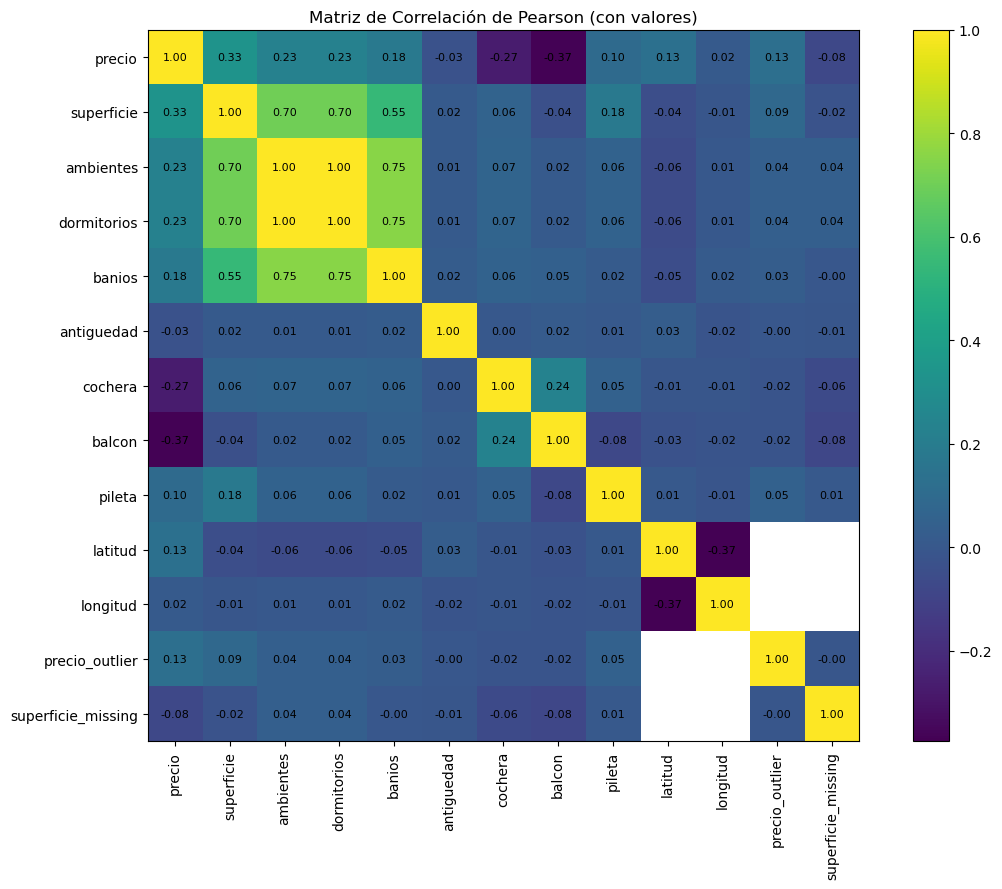

In [29]:
df_numeric = df_final.select_dtypes(include=['number'])
corr = df_numeric.corr(method='pearson')
fig, ax = plt.subplots(figsize=(12, 9))

cax = ax.imshow(corr)
fig.colorbar(cax)


ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        
        if not np.isnan(value):
            ax.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )


plt.title("Matriz de Correlación de Pearson (con valores)")
plt.tight_layout()

plt.show()

In [30]:
df_final.to_parquet("dataset_unificado_limpio.parquet", index=False)
df_final.to_csv("dataset_unificado_limpio.csv", index=False)
print("\n✓ Guardado en dataset_unificado_limpio.parquet / .csv")



✓ Guardado en dataset_unificado_limpio.parquet / .csv
